# Embedding-probe bake-off

Different workflow from the fine-tune notebook:

1. **Freeze** an embedding model (sentence-transformers, BGE, E5, Qwen3-Embedding, …)
2. **Encode** every memory once → fixed-size vector
3. **Fit** a small classifier (`LogisticRegression`) on those vectors

Why this often **beats fine-tuned BERT on small datasets**:
- The encoder was pretrained with a *sentence-similarity* objective → its vectors already separate semantically distinct sentences
- Only the classifier (a few thousand params) trains → tiny data is enough
- No GPU memory hit from backprop through the encoder; runs comfortably on Mac MPS / CPU / 4 GB CUDA

Auto-detects CUDA / MPS / CPU. Same code on Windows-NVIDIA and Mac-Silicon.

## 1. Environment

In [1]:
import sys, platform, time
from pathlib import Path
import torch, numpy as np, pandas as pd
from crimellm import resolve_device, linear_probe

info = resolve_device()
print(f"Python : {sys.version.split()[0]}")
print(f"Torch  : {torch.__version__}")
print(f"OS     : {platform.system()} {platform.machine()}")
print(f"Device : {info}")

Python : 3.11.14
Torch  : 2.12.0
OS     : Darwin arm64
Device : mps:Apple Silicon (arm64) (fp16=False, bf16=False)


## 2. Data

Same `data/sample.csv` (or your real CSV). The probe pattern is exactly where small datasets *should* perform well, so this is the place to actually trust early results.

In [2]:
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
csv_path = PROJECT_ROOT / "data" / "sample.csv"
df = pd.read_csv(csv_path)

id2label = {0: "no", 1: "yes", 2: "unclear"}
label_names = [id2label[i] for i in range(3)]

train_texts, eval_texts, train_labels, eval_labels = train_test_split(
    df["text"].tolist(), df["label"].tolist(),
    test_size=0.33, stratify=df["label"], random_state=42,
)
print(f"train={len(train_texts)}  eval={len(eval_texts)}")

train=8  eval=4


## 3. Candidate embedding models

| model | params | dim | langs | notes |
|-------|-------:|----:|-------|-------|
| `sentence-transformers/all-MiniLM-L6-v2` | 22M | 384 | EN | tiny, fast, surprisingly strong |
| `sentence-transformers/all-mpnet-base-v2` | 110M | 768 | EN | classic strong baseline |
| `BAAI/bge-small-en-v1.5` | 33M | 384 | EN | top of the small-model leaderboard |
| `BAAI/bge-base-en-v1.5` | 110M | 768 | EN | bigger sibling |
| `intfloat/multilingual-e5-small` | 118M | 384 | 100+ (incl. Danish) | go-to multilingual small |
| `Qwen/Qwen3-Embedding-0.6B` | 600M | 1024 | 100+ | state-of-the-art for size, multilingual |

**Skipped on 4 GB GPU / Mac:** `nvidia/llama-embed-nemotron-8b` (~16 GB fp16), `microsoft/harrier-oss-v1-27b` (massive generative LLM, wrong tool).

Some models (e.g. Qwen3) need `trust_remote_code=True`.

In [13]:
CANDIDATES = [
    # (name, trust_remote_code)
    ("Qwen/Qwen3-Embedding-4B", True),
    ("sentence-transformers/all-MiniLM-L6-v2", False),

    
]

## 4. Run the probe

For each model: encode train + eval texts → fit `LogisticRegression` (balanced class weights) → report macro-F1, accuracy, per-class F1, embed/fit seconds.

Errors per model (e.g. download failure, missing `trust_remote_code`) are caught and reported, the loop continues.

In [ ]:
results = []
reports = {}
for name, trust in CANDIDATES:
    print(f"\n=== {name} ===")
    r = linear_probe(
        name, train_texts, train_labels, eval_texts, eval_labels,
        label_names=label_names, batch_size=16, trust_remote_code=trust,
    )
    if r.error:
        print("  SKIP:", r.error)
    else:
        print(f"  macro_f1={r.macro_f1:.4f}  acc={r.accuracy:.4f}  dim={r.dim}  embed={r.embed_seconds:.1f}s  fit={r.fit_seconds:.3f}s")
        reports[name] = r.report
    results.append(r)


=== Qwen/Qwen3-Embedding-4B ===


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/30.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

## 5. Leaderboard

In [5]:
rows = []
for r in results:
    row = {
        "model": r.model_name,
        "macro_f1": None if r.error else round(r.macro_f1, 4),
        "accuracy": None if r.error else round(r.accuracy, 4),
        "dim": r.dim or None,
        "embed_s": None if r.error else round(r.embed_seconds, 1),
        "fit_s": None if r.error else round(r.fit_seconds, 3),
        "error": r.error,
    }
    if not r.error:
        for lbl, v in zip(label_names, r.per_class_f1):
            row[f"f1_{lbl}"] = round(v, 4)
    rows.append(row)
leader = pd.DataFrame(rows).sort_values("macro_f1", ascending=False, na_position="last").reset_index(drop=True)
leader

,model,macro_f1,accuracy,dim,embed_s,fit_s,error,f1_no,f1_yes,f1_unclear
0,sentence-transformers/all-MiniLM-L6-v2,0.7778,0.75,384,11.4,0.011,None,1.0,0.6667,0.6667
1,sentence-transformers/all-mpnet-base-v2,0.7778,0.75,768,53.0,0.016,None,1.0,0.6667,0.6667
2,BAAI/bge-base-en-v1.5,0.6000,0.75,768,40.9,0.008,None,1.0,0.0000,0.8000
3,intfloat/multilingual-e5-small,0.6000,0.75,384,45.0,0.005,None,1.0,0.0000,0.8000
4,BAAI/bge-small-en-v1.5,0.5000,0.50,384,18.5,0.004,None,1.0,0.0000,0.5000
5,Qwen/Qwen3-Embedding-0.6B,0.5000,0.50,1024,125.6,0.018,None,1.0,0.5000,0.0000


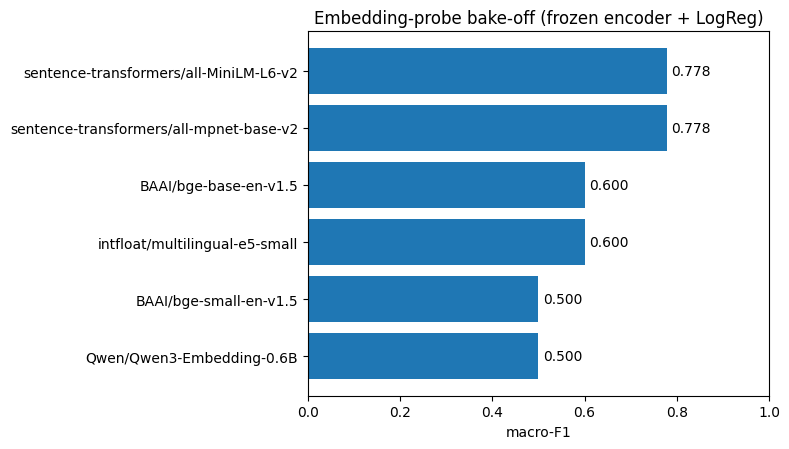

In [6]:
import matplotlib.pyplot as plt

plot_df = leader.dropna(subset=["macro_f1"])
fig, ax = plt.subplots(figsize=(8, 0.6 * len(plot_df) + 1))
ax.barh(plot_df["model"], plot_df["macro_f1"])
ax.invert_yaxis()
ax.set_xlabel("macro-F1")
ax.set_xlim(0, 1)
ax.set_title("Embedding-probe bake-off (frozen encoder + LogReg)")
for i, v in enumerate(plot_df["macro_f1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 6. Winner — per-class breakdown

In [7]:
winner = leader.iloc[0]["model"]
print(f"Winner: {winner}\n")
print(reports[winner])

Winner: sentence-transformers/all-MiniLM-L6-v2

              precision    recall  f1-score   support

          no       1.00      1.00      1.00         1
         yes       0.50      1.00      0.67         1
     unclear       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.83      0.78         4
weighted avg       0.88      0.75      0.75         4



## 7. Inference helper

Reuse the winner: encode new text once, predict with the fitted `LogisticRegression`.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from crimellm import encode_texts

# Refit final classifier on ALL labeled data using the winning encoder.
trust = dict(CANDIDATES)[winner]
X_all, st_model = encode_texts(winner, df["text"].tolist(), trust_remote_code=trust)
final_clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_all, df["label"].values)

def classify(texts):
    if isinstance(texts, str):
        texts = [texts]
    vecs = st_model.encode(texts, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
    probs = final_clf.predict_proba(vecs)
    preds = probs.argmax(-1)
    return [
        {"label": id2label[int(p)], "probs": {id2label[i]: float(pr) for i, pr in enumerate(row)}}
        for p, row in zip(preds, probs)
    ]

for r in classify([
    "He broke into the shop and emptied the till.",
    "She returned the wallet she found on the bench.",
    "Voices were heard but nothing was visible.",
]):
    print(r)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

{'label': 'yes', 'probs': {'no': 0.2721223831176758, 'yes': 0.49192875623703003, 'unclear': 0.235948845744133}}
{'label': 'no', 'probs': {'no': 0.4326331615447998, 'yes': 0.30398181080818176, 'unclear': 0.26338502764701843}}
{'label': 'unclear', 'probs': {'no': 0.2399083524942398, 'yes': 0.2612859308719635, 'unclear': 0.4988057613372803}}
{'label': 'no', 'probs': {'no': 0.3865906596183777, 'yes': 0.29608088731765747, 'unclear': 0.31732848286628723}}


## Notes

- **When this beats fine-tuning:** small labeled set (<500 rows), short text, multilingual input. The embedding model has already done the hard pretraining work.
- **When fine-tuning catches up:** lots of labels (1000s+) and your domain has terms the embedder didn't see well in pretraining. At that point retrain the *winner* via the fine-tune notebook with `freeze_encoder=False`.
- **Tuning the head:** swap `LogisticRegression` for `sklearn.svm.LinearSVC` or a small `MLPClassifier`. Tune `C` for LogReg (try `0.1`, `1`, `10`).
- **Statistical noise:** with tiny eval splits a single sample flip moves macro-F1 a lot. Repeat with multiple `random_state`s and average before trusting the ranking.
- **Persistence:** to ship, `joblib.dump(final_clf, "head.joblib")` and save the embedder name. At inference, reload both.